In [1]:
pip install opencv-python "numpy<2" matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230108/Downloads/cat.jpg', cv2.IMREAD_GRAYSCALE)


# Part 1 – Power Law Transformation (Gamma Correction)

### Challenge 1.1




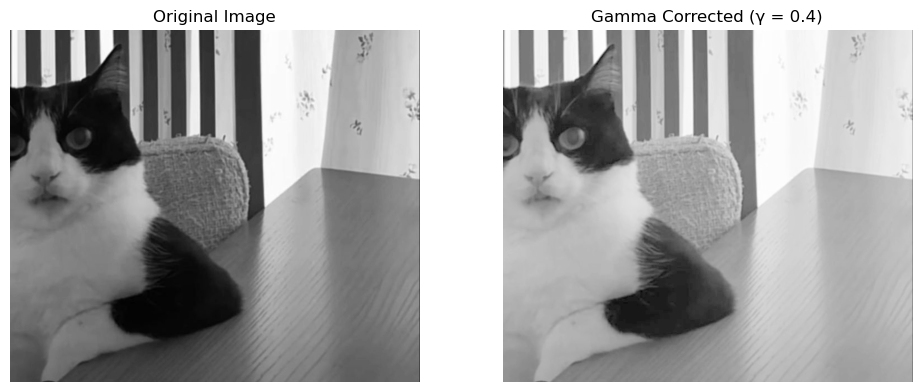

In [6]:
def gamma_correction(image, gamma):
    img_norm = image / 255.0
    img_corrected = img_norm ** gamma
    img_out = (img_corrected * 255).astype(np.uint8)
    return img_out

corrected = gamma_correction(image, 0.4)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(corrected, cmap='gray')
axes[1].set_title('Gamma Corrected (γ = 0.4)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 1.2 – Gamma Curve Analysis




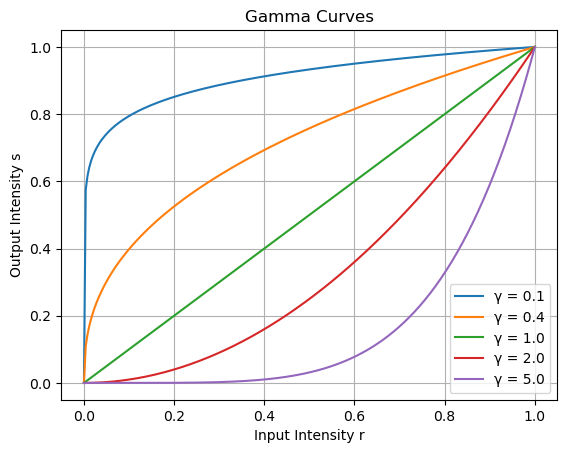

In [7]:
r = np.linspace(0, 1, 256)
gamma_values = [0.1, 0.4, 1.0, 2.0, 5.0]

for gamma in gamma_values:
    s = r ** gamma
    plt.plot(r, s, label=f'γ = {gamma}')

plt.xlabel('Input Intensity r')
plt.ylabel('Output Intensity s')
plt.title('Gamma Curves')
plt.legend()
plt.grid(True)
plt.show()


### Challenge 1.3 – Comparative Study




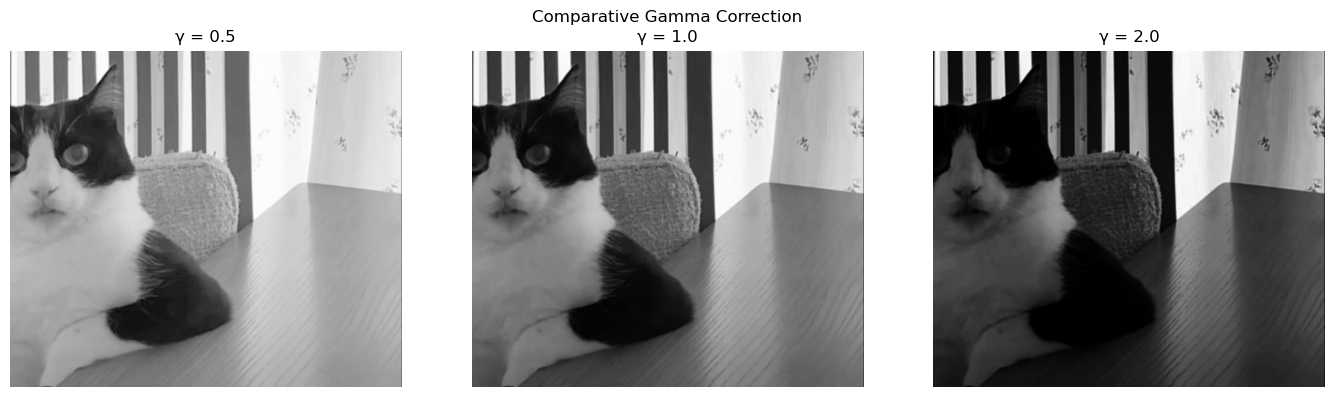

In [8]:
gammas = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, gamma in zip(axes, gammas):
    result = gamma_correction(image, gamma)
    ax.imshow(result, cmap='gray')
    ax.set_title(f'γ = {gamma}')
    ax.axis('off')

plt.suptitle('Comparative Gamma Correction')
plt.tight_layout()
plt.show()


# Part 2 – Basic Intensity Transformations

### Challenge 2.1 – Image Negative



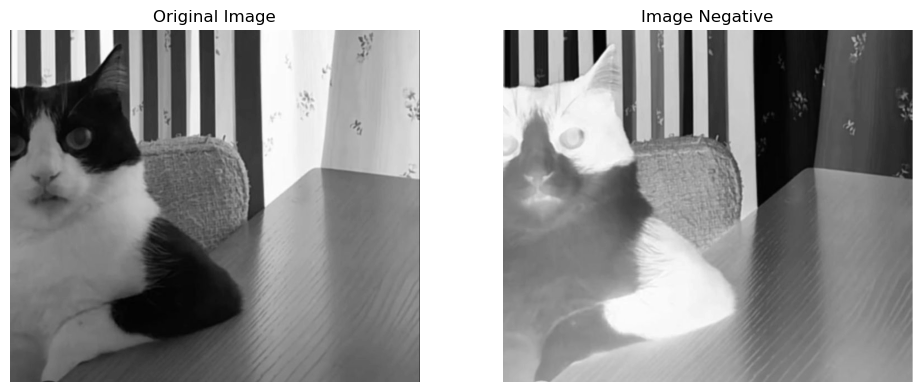

In [9]:
def image_negative(image):
    return (255 - image).astype(np.uint8)

negative = image_negative(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(negative, cmap='gray')
axes[1].set_title('Image Negative')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 2.2 – Intensity Range Mapping




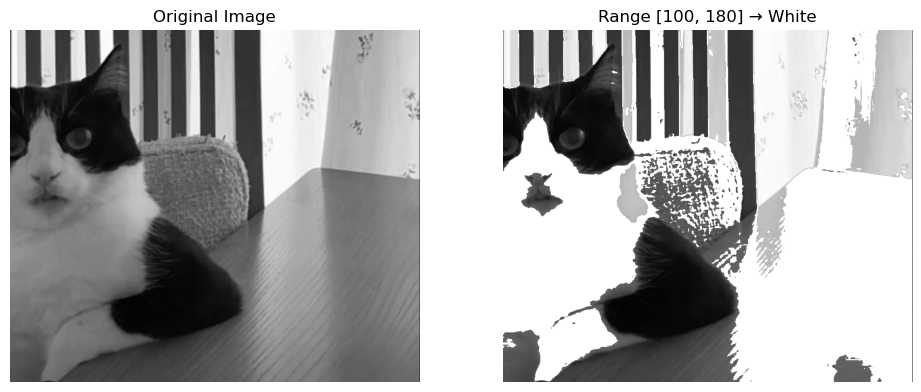

In [10]:
def intensity_range_mapping(image, A, B):
    result = image.copy()
    result[(result >= A) & (result <= B)] = 255
    return result

mapped = intensity_range_mapping(image, 100, 180)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mapped, cmap='gray')
axes[1].set_title('Range [100, 180] → White')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 2.3 – Integrated Enhancement




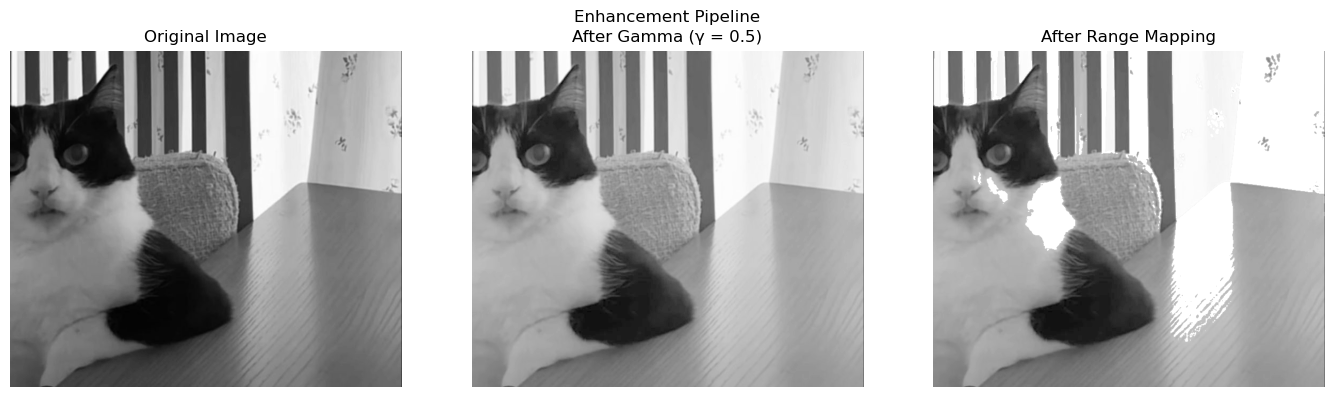

In [11]:
step1 = gamma_correction(image, 0.5)
step2 = intensity_range_mapping(step1, 200, 240)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(step1, cmap='gray')
axes[1].set_title('After Gamma (γ = 0.5)')
axes[1].axis('off')

axes[2].imshow(step2, cmap='gray')
axes[2].set_title('After Range Mapping')
axes[2].axis('off')

plt.suptitle('Enhancement Pipeline')
plt.tight_layout()
plt.show()


# Part 3 – Advanced Optimization Challenge

### Challenge 3.1 – Performance & Robustness



### Final Task



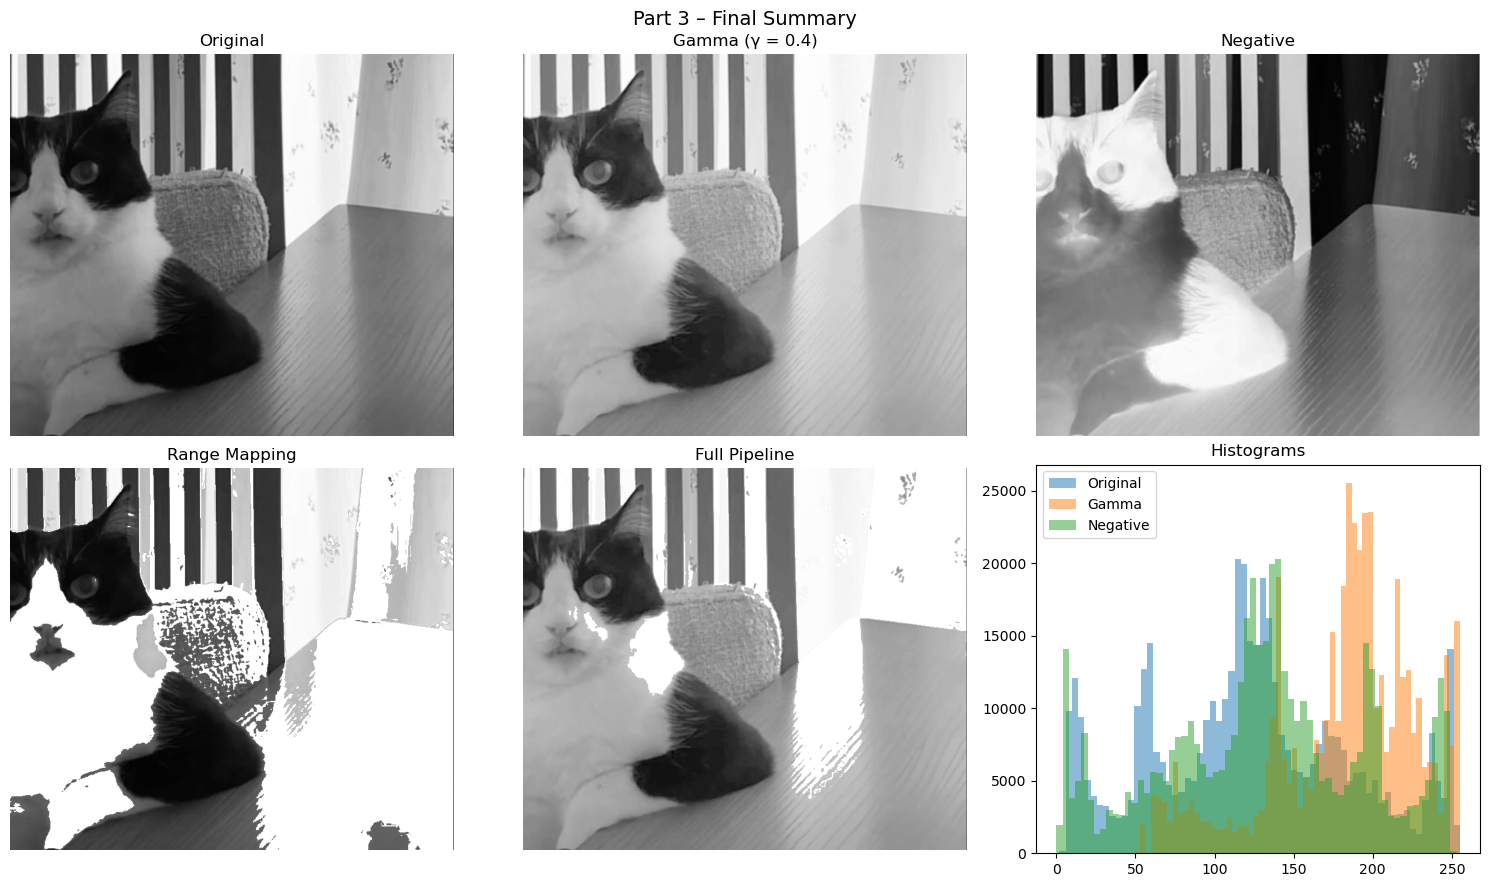

In [12]:
def gamma_correction(image, gamma):
    return ((image / 255.0) ** gamma * 255).astype(np.uint8)

def image_negative(image):
    return (255 - image).astype(np.uint8)

def intensity_range_mapping(image, A, B):
    result = image.copy()
    result[(result >= A) & (result <= B)] = 255
    return result

gc      = gamma_correction(image, 0.4)
neg     = image_negative(image)
mapped  = intensity_range_mapping(image, 100, 180)
final   = intensity_range_mapping(gamma_correction(image, 0.5), 200, 240)


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(image, cmap='gray');  axes[0, 0].set_title('Original')
axes[0, 1].imshow(gc, cmap='gray');     axes[0, 1].set_title('Gamma (γ = 0.4)')
axes[0, 2].imshow(neg, cmap='gray');    axes[0, 2].set_title('Negative')
axes[1, 0].imshow(mapped, cmap='gray'); axes[1, 0].set_title('Range Mapping')
axes[1, 1].imshow(final, cmap='gray');  axes[1, 1].set_title('Full Pipeline')


axes[1, 2].hist(image.ravel(), bins=64, alpha=0.5, label='Original')
axes[1, 2].hist(gc.ravel(),    bins=64, alpha=0.5, label='Gamma')
axes[1, 2].hist(neg.ravel(),   bins=64, alpha=0.5, label='Negative')
axes[1, 2].set_title('Histograms')
axes[1, 2].legend()

for ax in axes.ravel():
    ax.axis('off') if ax != axes[1, 2] else None

plt.suptitle('Part 3 – Final Summary', fontsize=14)
plt.tight_layout()
plt.show()